<a href="https://colab.research.google.com/github/iwinshijo/AI-ML-Internship/blob/main/WalmartPractice_Day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Missing Values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Summary Statistics:
              Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%      12.000000  5.533501e+05      0.000000    47.460000     2.933000   
50%      23.000000  9.607460e+05      0.000000    62.670000     3.445000   
75%      34.000000  1.420159e+06      0.000000    74.940000     3.735000   
max      45.000000  3.818686e+06      1.000000   100.140000     4.468000   

               CPI  Unemployment  
count  6435.000000   6435.000000  
mean    171.578394      7.999151  
std      39.35

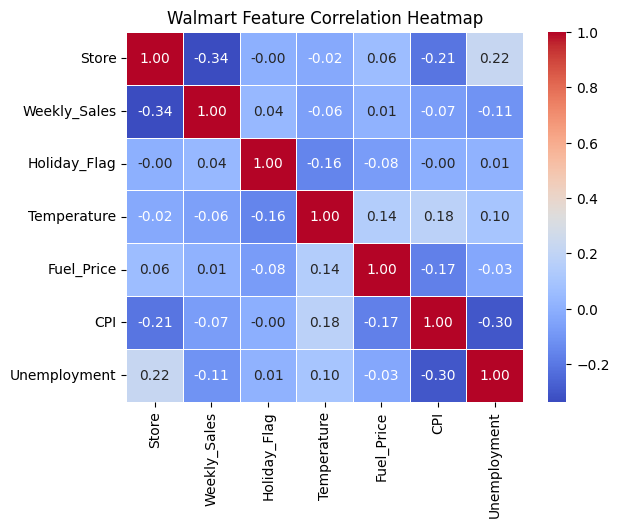

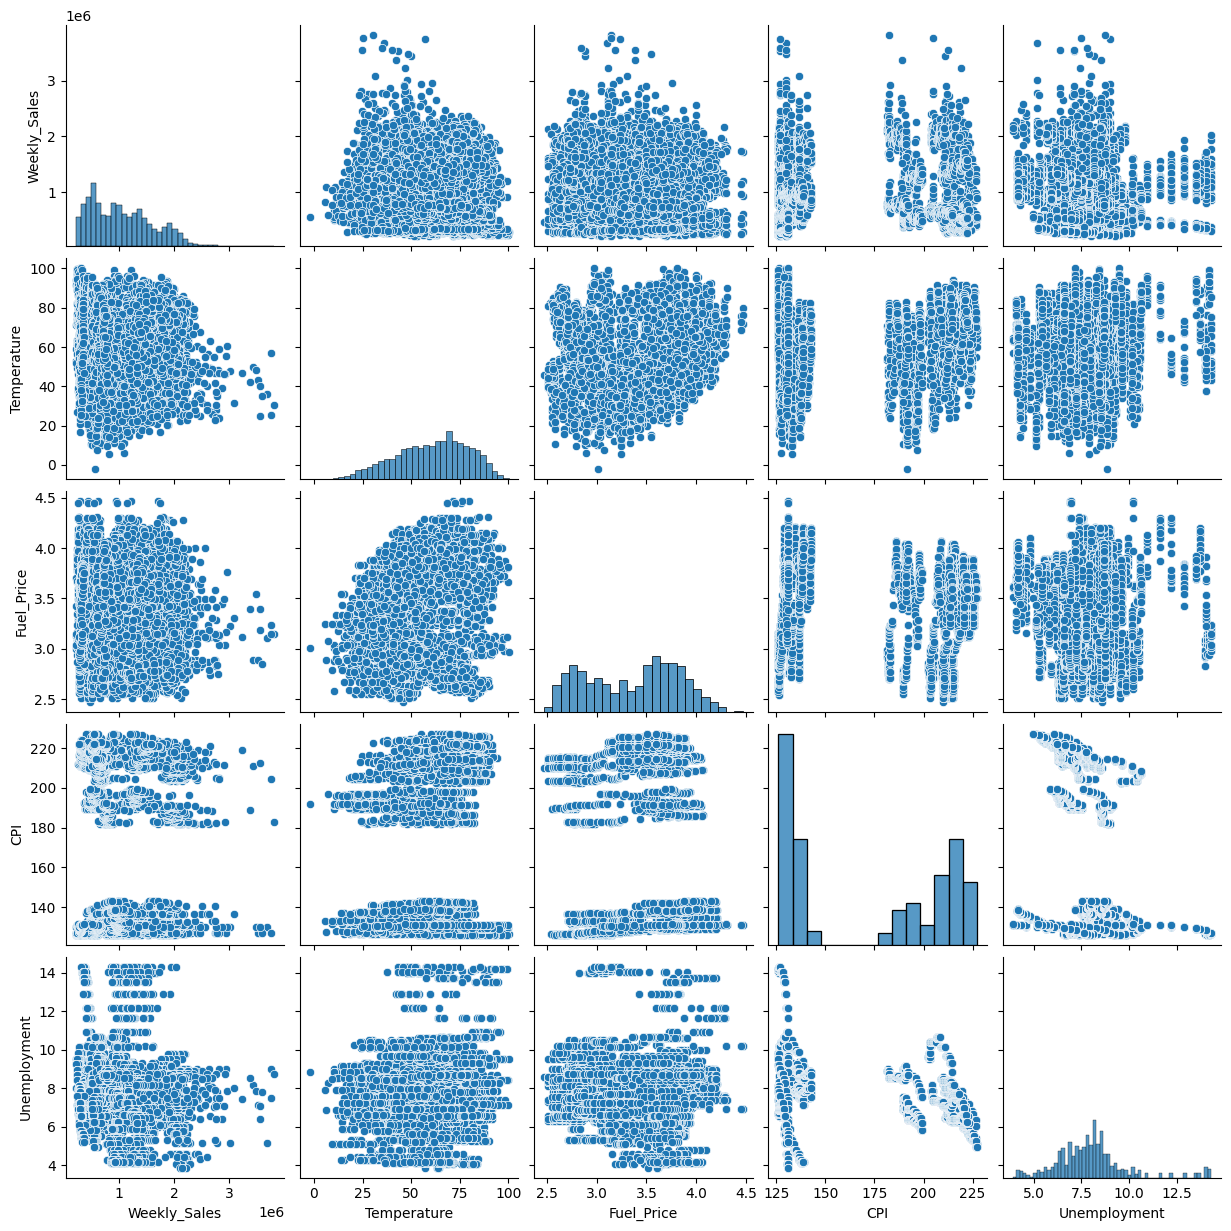

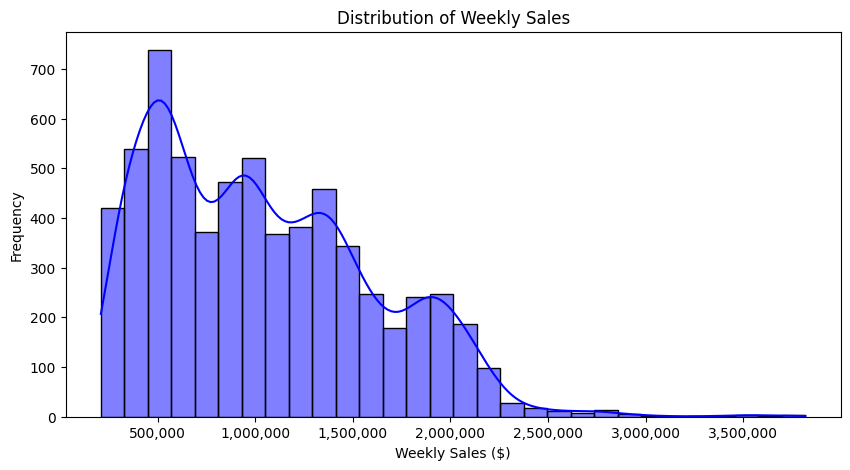

R² Score: 0.1481
RMSE: 523884.7405


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
df=pd.read_csv('/content/Walmart Data Analysis and Forcasting.csv')




import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")

print("Missing Values:\n", df.isnull().sum())

print("\nSummary Statistics:\n", df.describe())

numeric_df = df.drop(columns=['Date'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Walmart Feature Correlation Heatmap")
plt.show()

sns.pairplot(df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']])
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df['Weekly_Sales'], bins=30, kde=True, color='blue')
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales ($)")
plt.ylabel("Frequency")

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.show()


X = df.drop(columns=["Weekly_Sales", "Date"])
y = df["Weekly_Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

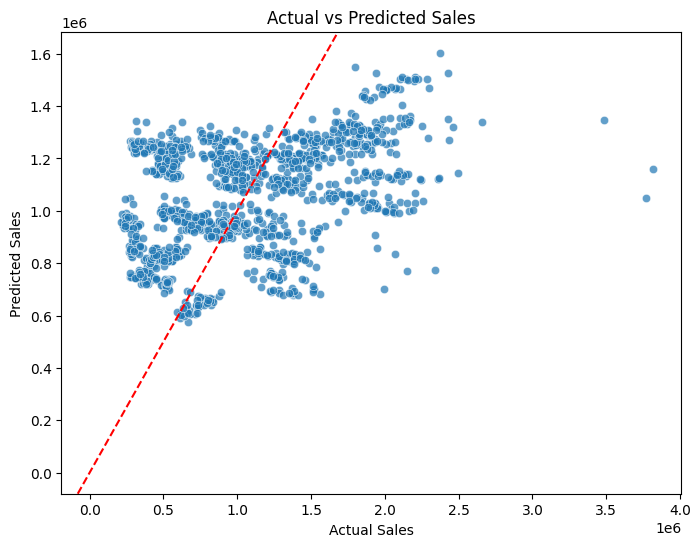

In [2]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

In [3]:
import pandas as pd
from scipy.stats import skew

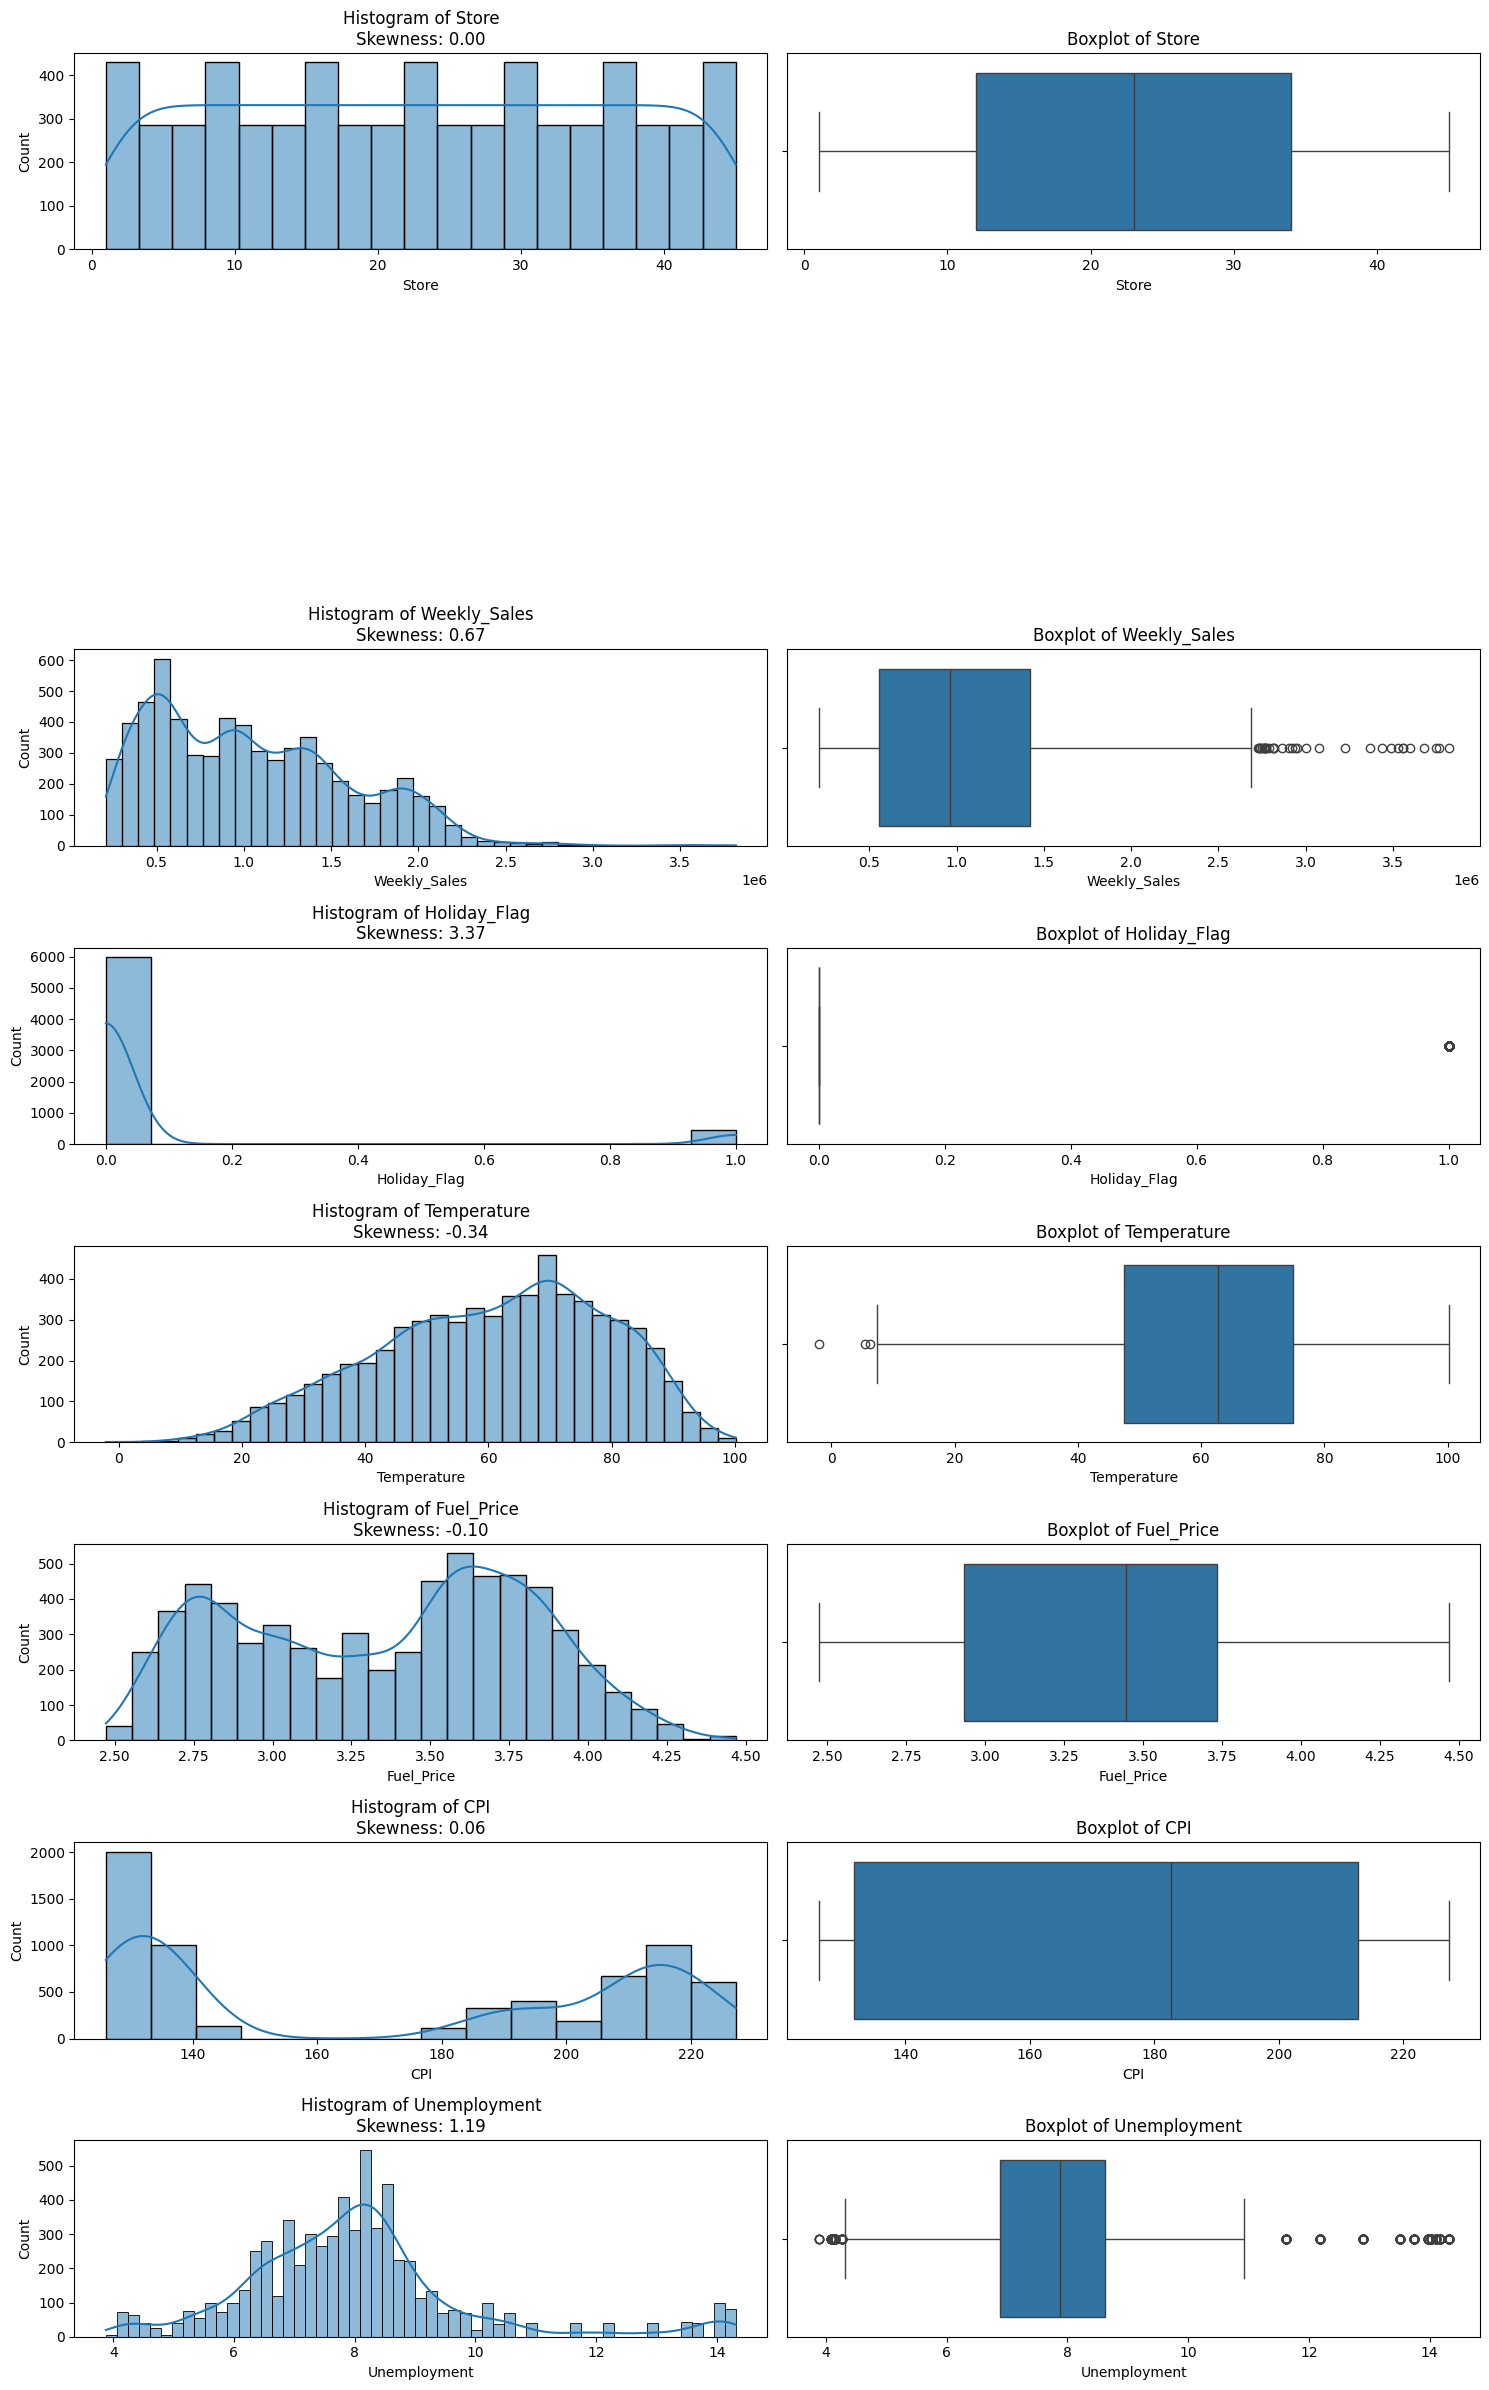

In [5]:
skewness=df.skew(numeric_only=True)

num_cols=len(df.columns)
plt.figure(figsize=(15,num_cols * 3))

for i, col in enumerate(df.columns):

  if df[col].dtype != 'object' and df[col].dtype != '<M8[ns]':
    plt.subplot(num_cols,2,2*i +1)
    sns.histplot(df[col],kde=True)
    plt.title(f'Histogram of {col}\nSkewness: {skewness[col]:.2f}')

    plt.subplot(num_cols,2,2*i+2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [6]:
import numpy as np

In [7]:
skewed_cols=df.skew(numeric_only=True).abs()
highly_skewed = skewed_cols[skewed_cols>1].index
negatively_skewed = skewed_cols[skewed_cols<1].index
print("Highly skewed columns:\n",highly_skewed)
print("Negatively skewed columns:\n",negatively_skewed)

Highly skewed columns:
 Index(['Holiday_Flag', 'Unemployment'], dtype='object')
Negatively skewed columns:
 Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI'], dtype='object')


In [8]:
df[highly_skewed]=df[highly_skewed].apply(lambda x:np.log1p(x))

In [9]:
from sklearn.preprocessing import PowerTransformer

pt=PowerTransformer(method='yeo-johnson')
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])

In [10]:
df.skew(numeric_only=True)

,0
Store,-0.228157
Weekly_Sales,-0.049912
Holiday_Flag,3.373499
Temperature,-0.141684
Fuel_Price,-0.055815
CPI,0.010477
Unemployment,0.226991


In [12]:
X=df.drop(columns=['Weekly_Sales', 'Date'])
y=df["Weekly_Sales"]

In [13]:
X_train, X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)

r2 = r2_score(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1270
RMSE: 0.9464


In [14]:
from sklearn.ensemble import RandomForestRegressor

In [15]:
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

y_pred=rf_model.predict(X_test)
r2=r2_score(y_test,y_pred)
rmse=mean_squared_error(y_test,y_pred)**0.5

print(f"Random forest R²  Score: {r2:.4f}")
print(f"Random forest RMSE: {rmse:.4f}")

Random forest R²  Score: 0.9619
Random forest RMSE: 0.1976
